In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
#------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

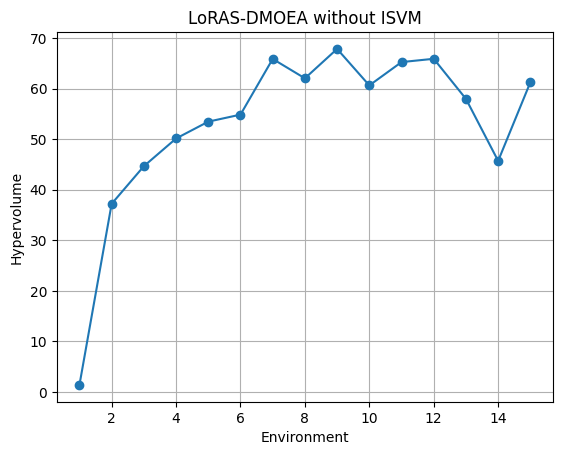

In [68]:
class LoRAS:
    def __init__(self, k=8, num_shadow_points=10, sigma=0.005, 
                 num_aff_comb=5, random_state=42):
        self.k = k
        self.num_shadow_points = num_shadow_points
        self.sigma = sigma
        self.num_aff_comb = num_aff_comb
        np.random.seed(random_state)

    def _generate_shadowsamples(self, point, num_shadows):
        shadows = []
        for _ in range(num_shadows):
            noise = np.random.normal(0, self.sigma, point.shape)
            shadows.append(point + noise)
        return np.array(shadows)

    def _affine_combination(self, points, num_combinations):
        synthetic = []
        for _ in range(num_combinations):
            idx = np.random.choice(len(points), 
                                   size=min(self.num_aff_comb, len(points)), 
                                   replace=False)
            pts = points[idx]
            w = np.random.random(len(pts))
            w /= w.sum()
            synthetic.append((pts * w[:,None]).sum(axis=0))
        return np.array(synthetic)

    def fit_resample(self, minority_points, num_generated):
        if len(minority_points)==0:
            return np.empty((0, minority_points.shape[1]))
        nbrs = None
        if len(minority_points)>self.k:
            nbrs = NearestNeighbors(n_neighbors=self.k+1).fit(minority_points)
        synthetic = []
        for pt in minority_points:
            if nbrs:
                d,i = nbrs.kneighbors([pt])
                neigh = minority_points[i[0][1:]]
            else:
                neigh = minority_points
            shadows = np.vstack([self._generate_shadowsamples(n, self.num_shadow_points)
                                 for n in neigh])
            combos = max(1, num_generated//len(minority_points))
            syn = self._affine_combination(shadows, combos)
            synthetic.extend(syn)
        return np.array(synthetic[:num_generated])

class LoRAS_MOEA:
    def __init__(self, pop_size=100, random_state=42):
        self.pop_size = pop_size
        self.loras = LoRAS(random_state=random_state)

    def _evaluate(self, pop, t):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # f1: distance to time-varying target
        f1 = np.sum((pop - shift) ** 2, axis=1)
    
        # f2: distance to another target + constraint penalty
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
             10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)
    
        # two-objective minimization
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_shifted_rastrigin(self, pop, t):
        shift1 = t * 0.05
        shift2 = 1 - t * 0.05

        f1 = np.sum((pop - shift1) ** 2, axis=1)  # Sphere function with shift
        A = 10
        n = pop.shape[1]
        z = pop - shift2
        f2 = A * n + np.sum(z ** 2 - A * np.cos(2 * np.pi * z), axis=1)  # Rastrigin shifted
        return np.vstack([f1, f2]).T
    
    def _evaluate_dynamic_time_linkage(self, pop, t, prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # Time-linkage: bias from previous environment
        if prev_pop_mean is not None:
            linkage = 0.1 * np.sum((pop - prev_pop_mean) ** 2, axis=1)
        else:
            linkage = 0.0
    
        f1 = np.sum((pop - shift) ** 2, axis=1) + linkage
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + linkage
    
        # Time-varying box constraint: upper bound oscillates
        upper = 0.8 + 0.2 * np.sin(np.pi * t / 10)
        violation = np.sum(np.maximum(0, pop - upper), axis=1)
        penalty = 15 * violation
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T
    



    
    def _evaluate_dynamic_dtlz2(self, pop, t):
        # t modifies the shape of Pareto front over time using a sinusoid
        n = pop.shape[1]
        shift = 0.2 * np.sin(np.pi * t / 15)

        g = np.sum((pop[:, :-1] - shift) ** 2, axis=1)
        theta = (np.pi / 2) * pop[:, -1]

        f1 = (1 + g) * np.cos(theta)
        f2 = (1 + g) * np.sin(theta)
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_history_dtlz2(self, pop, t, prev_pop_mean=None):
        # pop: (N, n), n >= 2
        n = pop.shape[1]
    
        # Time-varying shift on tail variables
        base_shift = 0.2 * np.sin(np.pi * t / 18.0)
        z = pop[:, 1:] - base_shift
    
        g_base = np.sum((z - 0.5) ** 2, axis=1)
    
        # History bias in g using previous mean of tail variables
        if prev_pop_mean is not None:
            tail_mean = prev_pop_mean[1:]
            history = np.sum((z - tail_mean) ** 2, axis=1)
        else:
            history = 0.0
    
        g = g_base + 0.2 * history
    
        theta = 0.5 * np.pi * pop[:, 0]
    
        f1 = (1.0 + g) * np.cos(theta)
        f2 = (1.0 + g) * np.sin(theta)
    
        # Dynamic upper bound on all variables
        upper = 0.9 + 0.1 * np.sin(np.pi * t / 12.0)
        viol = np.sum(np.maximum(0.0, pop - upper), axis=1)
        penalty = 20.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_velocity_linkage(self, pop, t, prev_pop_mean=None, prev_prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.3 + 0.3 * np.sin(np.pi * t / 30)
    
        # Velocity of the population mean across two previous environments
        if prev_pop_mean is not None and prev_prev_pop_mean is not None:
            vel = prev_pop_mean - prev_prev_pop_mean
            vel_term = 0.1 * np.sum((pop - (prev_pop_mean + vel)) ** 2, axis=1)
        else:
            vel_term = 0.0
    
        # Moving quadratic objectives
        f1 = np.sum((pop - shift) ** 2, axis=1) + vel_term
        f2 = np.sum((pop - (1.0 - shift)) ** 2, axis=1) + vel_term
    
        # Simple sum constraint (no oscillation here)
        viol = np.maximum(0.0, np.sum(pop, axis=1) - 1.6)
        penalty = 15.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    def _pareto(self, pop, obj):
        n = len(pop)
        mask = np.ones(n, bool)
        for i in range(n):
            for j in range(n):
                if i!=j and np.all(obj[j]<=obj[i]) and np.any(obj[j]<obj[i]):
                    mask[i]=False
                    break
        return pop[mask], obj[mask]

    def optimize(self, bounds, n_env=10, n_gen=50, minority_samples=None):
        # use oversampled positives as initial population
        if minority_samples is None or len(minority_samples)==0:
            population = np.random.uniform(bounds[:,0], bounds[:,1],
                                           (self.pop_size, bounds.shape[0]))
        else:
            oversampled = self.loras.fit_resample(minority_samples, self.pop_size)
            population = np.vstack([minority_samples, oversampled])[:self.pop_size]
        perf_hist = []
        for env in range(n_env):
            best_objs = []
            for gen in range(n_gen):
                obj = self._evaluate_dynamic_history_dtlz2(population, env)
                pop_p, obj_p = self._pareto(population, obj)
                best_objs.append([obj_p[:,0].min(), obj_p[:,1].min()])
                # mutation
                for i in range(len(population)):
                    if np.random.rand()<0.1:
                        m = np.random.normal(0,0.1, population.shape[1])
                        population[i] = np.clip(population[i]+m, 
                                                bounds[:,0], bounds[:,1])
            # record hypervolume = f1_min * f2_min
            last = best_objs[-1]
            perf_hist.append(last[0]*last[1])
            # for next env, treat current Pareto as new population
            population = pop_p.copy()
            # if too small, refill randomly
            if len(population)<self.pop_size:
                extra = np.random.uniform(bounds[:,0], bounds[:,1],
                                          (self.pop_size-len(population),
                                           bounds.shape[0]))
                population = np.vstack([population, extra])
        return perf_hist
   
# Example usage
if __name__=='__main__':
    # Suppose minority class data X_min (shape [n_min, dim])
    # Load or define X_min here
    # e.g., X_min = np.random.uniform(-2,2,(10,2))
   
    X_min = np.random.uniform(-2,2,(10,2))
    bounds = np.array([[-2,2],[-2,2]])
    moea = LoRAS_MOEA(pop_size=100)
    perf = moea.optimize(bounds, n_env=15, n_gen=30, minority_samples=X_min)
    plt.plot(range(1,16), perf, marker='o')
    plt.xlabel('Environment')
    plt.ylabel('Hypervolume')
    plt.title('LoRAS-DMOEA without ISVM')
    plt.grid(True)
    plt.show()
    


In [69]:
class MOEA_Random:
    def __init__(self, pop_size=100, random_state=42):
        self.pop_size = pop_size
        self.loras = LoRAS(random_state=random_state)

    def _evaluate(self, pop, t):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # f1: distance to time-varying target
        f1 = np.sum((pop - shift) ** 2, axis=1)
    
        # f2: distance to another target + constraint penalty
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
             10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)
    
        # two-objective minimization
        return np.vstack([f1, f2]).T


    # def _evaluate(self, pop, t):
        
    #     n = pop.shape[1]
    #     shift = 0.5 * np.sin(np.pi * t / 20)

    #     # Add more realistic multi-objective functions
    #     f1 = np.sum((pop - shift) ** 2, axis=1)
    #     f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + \
    #          10 * np.maximum(0, np.sum(pop, axis=1) - 1.5)

    #     # Add convergence and diversity metrics
    #     f3 = np.var(pop, axis=1)  # Diversity objective
    #     return np.vstack([f1, f2, f3]).T
        
    #     # f1 = np.sum((pop - t*0.1)**2, axis=1)
    #     # f2 = np.sum((pop - 1 + t*0.1)**2, axis=1)
    #     # return np.vstack([f1,f2]).T
        
    def _evaluate_dynamic_shifted_rastrigin(self, pop, t):
        shift1 = t * 0.05
        shift2 = 1 - t * 0.05

        f1 = np.sum((pop - shift1) ** 2, axis=1)  # Sphere function with shift
        A = 10
        n = pop.shape[1]
        z = pop - shift2
        f2 = A * n + np.sum(z ** 2 - A * np.cos(2 * np.pi * z), axis=1)  # Rastrigin shifted
        return np.vstack([f1, f2]).T
    
    def _evaluate_dynamic_time_linkage(self, pop, t, prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.5 * np.sin(np.pi * t / 20)
    
        # Time-linkage: bias from previous environment
        if prev_pop_mean is not None:
            linkage = 0.1 * np.sum((pop - prev_pop_mean) ** 2, axis=1)
        else:
            linkage = 0.0
    
        f1 = np.sum((pop - shift) ** 2, axis=1) + linkage
        f2 = np.sum((pop - (1 - shift)) ** 2, axis=1) + linkage
    
        # Time-varying box constraint: upper bound oscillates
        upper = 0.8 + 0.2 * np.sin(np.pi * t / 10)
        violation = np.sum(np.maximum(0, pop - upper), axis=1)
        penalty = 15 * violation
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    
    def _evaluate_dynamic_dtlz2(self, pop, t):
        # t modifies the shape of Pareto front over time using a sinusoid
        n = pop.shape[1]
        shift = 0.2 * np.sin(np.pi * t / 15)

        g = np.sum((pop[:, :-1] - shift) ** 2, axis=1)
        theta = (np.pi / 2) * pop[:, -1]

        f1 = (1 + g) * np.cos(theta)
        f2 = (1 + g) * np.sin(theta)
        return np.vstack([f1, f2]).T
        
    def _evaluate_dynamic_history_dtlz2(self, pop, t, prev_pop_mean=None):
        # pop: (N, n), n >= 2
        n = pop.shape[1]
    
        # Time-varying shift on tail variables
        base_shift = 0.2 * np.sin(np.pi * t / 18.0)
        z = pop[:, 1:] - base_shift
    
        g_base = np.sum((z - 0.5) ** 2, axis=1)
    
        # History bias in g using previous mean of tail variables
        if prev_pop_mean is not None:
            tail_mean = prev_pop_mean[1:]
            history = np.sum((z - tail_mean) ** 2, axis=1)
        else:
            history = 0.0
    
        g = g_base + 0.2 * history
    
        theta = 0.5 * np.pi * pop[:, 0]
    
        f1 = (1.0 + g) * np.cos(theta)
        f2 = (1.0 + g) * np.sin(theta)
    
        # Dynamic upper bound on all variables
        upper = 0.9 + 0.1 * np.sin(np.pi * t / 12.0)
        viol = np.sum(np.maximum(0.0, pop - upper), axis=1)
        penalty = 20.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T

    def _evaluate_dynamic_velocity_linkage(self, pop, t, prev_pop_mean=None, prev_prev_pop_mean=None):
        n = pop.shape[1]
        shift = 0.3 + 0.3 * np.sin(np.pi * t / 30)
    
        # Velocity of the population mean across two previous environments
        if prev_pop_mean is not None and prev_prev_pop_mean is not None:
            vel = prev_pop_mean - prev_prev_pop_mean
            vel_term = 0.1 * np.sum((pop - (prev_pop_mean + vel)) ** 2, axis=1)
        else:
            vel_term = 0.0
    
        # Moving quadratic objectives
        f1 = np.sum((pop - shift) ** 2, axis=1) + vel_term
        f2 = np.sum((pop - (1.0 - shift)) ** 2, axis=1) + vel_term
    
        # Simple sum constraint (no oscillation here)
        viol = np.maximum(0.0, np.sum(pop, axis=1) - 1.6)
        penalty = 15.0 * viol
    
        f1 += penalty
        f2 += penalty
        return np.vstack([f1, f2]).T




    def _pareto(self, pop, obj):
        n = len(pop)
        mask = np.ones(n, bool)
        for i in range(n):
            for j in range(n):
                if i!=j and np.all(obj[j]<=obj[i]) and np.any(obj[j]<obj[i]):
                    mask[i]=False
                    break
        return pop[mask], obj[mask]

    def optimize(self, bounds, n_env=10, n_gen=50, minority_samples=None):
        # use oversampled positives as initial population
        
        population = np.random.uniform(bounds[:,0], bounds[:,1],
                                           (self.pop_size, bounds.shape[0]))
       
        perf_hist = []
        for env in range(n_env):
            best_objs = []
            for gen in range(n_gen):
                obj = self._evaluate_dynamic_history_dtlz2(population, env)
                pop_p, obj_p = self._pareto(population, obj)
                best_objs.append([obj_p[:,0].min(), obj_p[:,1].min()])
                # mutation
                for i in range(len(population)):
                    if np.random.rand()<0.1:
                        m = np.random.normal(0,0.1, population.shape[1])
                        population[i] = np.clip(population[i]+m, 
                                                bounds[:,0], bounds[:,1])
            # record hypervolume = f1_min * f2_min
            last = best_objs[-1]
            perf_hist.append(last[0]*last[1])
            # for next env, treat current Pareto as new population
            population = pop_p.copy()
            # if too small, refill randomly
            if len(population)<self.pop_size:
                extra = np.random.uniform(bounds[:,0], bounds[:,1],
                                          (self.pop_size-len(population),
                                           bounds.shape[0]))
                population = np.vstack([population, extra])
        return perf_hist
   

Running LoRAS-MOEA ...
Th LoRAS_MOEA
[ 9.52524538 29.23745506 38.88829496 44.30885625 49.92966529 51.07320078
 53.68189426 56.76625892 57.82676945 59.51077105 60.28883162 58.65029671
 54.49837018 53.6159634  50.91770439]
RANDOM_MOEA
[35.18606162 43.37684025 51.05069191 54.53045637 55.96065514 55.54476223
 57.16775874 57.65742795 57.63161615 59.6432909  61.87730748 61.11755264
 57.14983014 53.44892446 54.55027839]


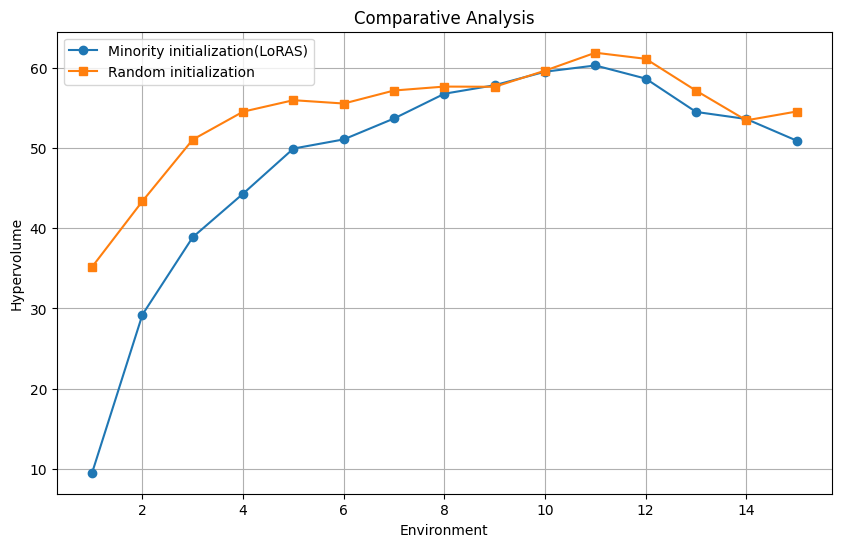

Average performance over 15 environments:
LoRAS MOEA: 48.58131
MOEA RANDOM: 54.39290


In [70]:

def comparative_analysis():
    bounds = np.array([[-2, 2], [-2, 2]])
    runs = 10
    n_env = 15
    n_gen = 30
    minority_samples = np.random.uniform(-2, 2, (10, 2))  # example minority samples
    
    loras_performances = []
    random_performances = []
    
    print("Running LoRAS-MOEA ...")
    for seed in range(runs):
        moea_loras = LoRAS_MOEA(pop_size=100, random_state=seed)
        perf = moea_loras.optimize(bounds, n_env=n_env, n_gen=n_gen,
                                   minority_samples=minority_samples)
        loras_performances.append(perf)
        
        
    for seed in range(runs):
        moea_loras_random = MOEA_Random(pop_size=100, random_state=seed)
        perf = moea_loras_random.optimize(bounds, n_env=n_env, n_gen=n_gen)
        random_performances.append(perf)
    
    
    loras_mean = np.mean(loras_performances, axis=0)
    random_mean = np.mean(random_performances, axis=0)

    print("Th LoRAS_MOEA")
    print(loras_mean)
    print("RANDOM_MOEA")
    print(random_mean)
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_env + 1), loras_mean, marker='o', label='Minority initialization(LoRAS)')
    plt.plot(range(1, n_env + 1), random_mean, marker='s', label='Random initialization')
    plt.xlabel('Environment')
    #plt.ylabel('Hypervolume (min f1 * min f2)')
    plt.ylabel('Hypervolume')
    plt.title('Comparative Analysis')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    print(f"Average performance over {n_env} environments:")
    print(f"LoRAS MOEA: {loras_mean.mean():.5f}")
    print(f"MOEA RANDOM: {random_mean.mean():.5f}")

if __name__ == '__main__':
    comparative_analysis()

Running LoRAS-MOEA ...
Running RANDOM-MOEA ...


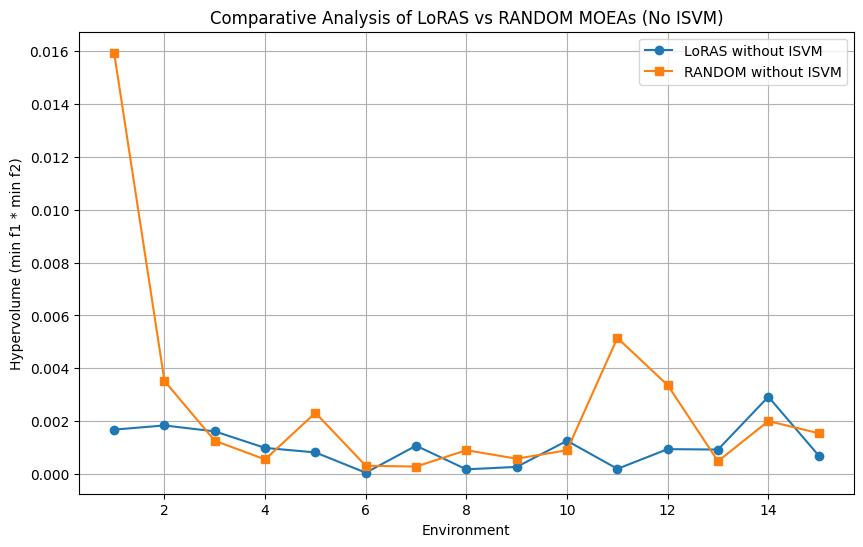


Per-environment paired t-tests (LoRAS lower than RANDOM):
Env  1: mean diff=-1.4255e-02, t=-2.157, p=0.0973
Env  2: mean diff=-1.6824e-03, t=-0.770, p=0.4843
Env  3: mean diff=3.5390e-04, t=0.470, p=0.6631
Env  4: mean diff=4.3509e-04, t=1.352, p=0.2479
Env  5: mean diff=-1.4978e-03, t=-0.634, p=0.5603
Env  6: mean diff=-2.6334e-04, t=-1.491, p=0.2101
Env  7: mean diff=7.8783e-04, t=1.193, p=0.2989
Env  8: mean diff=-7.2352e-04, t=-1.075, p=0.3430
Env  9: mean diff=-3.0938e-04, t=-1.265, p=0.2745
Env 10: mean diff=3.5606e-04, t=0.322, p=0.7633
Env 11: mean diff=-4.9518e-03, t=-1.593, p=0.1864
Env 12: mean diff=-2.4188e-03, t=-1.058, p=0.3499
Env 13: mean diff=4.4129e-04, t=0.760, p=0.4898
Env 14: mean diff=9.2109e-04, t=0.313, p=0.7703
Env 15: mean diff=-8.4398e-04, t=-1.440, p=0.2233

No environments where LoRAS is significantly worse than RANDOM.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
import seaborn as sns

def enhanced_statistical_analysis(loras_performances, random_performances, alpha=0.05):
    # """
    # Perform detailed statistical comparison between LoRAS and RANDOM performances.
    # Both inputs are lists/arrays with shape [runs, n_env] or just [runs] if aggregated.
    # """

    loras_perf = np.array(loras_performances)  # shape (runs, n_env)
    random_perf = np.array(random_performances)

    # Aggregate per run by averaging over environments if needed
    if loras_perf.ndim == 2:
        loras_mean_env = loras_perf.mean(axis=1)  # mean per run
    else:
        loras_mean_env = loras_perf

    if random_perf.ndim == 2:
        random_mean_env = random_perf.mean(axis=1)
    else:
        random_mean_env = random_perf

    # Basic summary statistics
    print("Summary Statistics:")
    print(f"LoRAS Mean: {loras_mean_env.mean():.5f}, Std: {loras_mean_env.std():.5f}")
    print(f"RANDOM Mean: {random_mean_env.mean():.5f}, Std: {random_mean_env.std():.5f}")

    # Paired t-test (assuming performance per run is paired)
    t_stat, p_val = ttest_rel(loras_mean_env, random_mean_env)
    print(f"\nPaired t-test: t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
    if p_val < alpha:
        print(f"Reject null hypothesis at alpha={alpha}: significant difference.")
    else:
        print(f"Fail to reject null hypothesis at alpha={alpha}: no significant difference.")

    # Wilcoxon signed-rank test (non-parametric alternative)
    try:
        w_stat, p_w = wilcoxon(loras_mean_env, random_mean_env)
        print(f"\nWilcoxon signed-rank test: statistic = {w_stat}, p-value = {p_w:.4f}")
        if p_w < alpha:
            print(f"Reject null hypothesis at alpha={alpha}: significant difference.")
        else:
            print(f"Fail to reject null hypothesis at alpha={alpha}: no significant difference.")
    except Exception as e:
        print(f"Wilcoxon test could not be performed: {e}")

    # Effect size: Cohen's d
    diff = loras_mean_env - random_mean_env
    cohen_d = diff.mean() / diff.std(ddof=1)
    print(f"\nEffect size (Cohen's d): {cohen_d:.4f}")

    # Confidence intervals for difference
    from scipy import stats
    n = len(diff)
    mean_diff = diff.mean()
    sem_diff = stats.sem(diff)
    ci = stats.t.interval(0.95, n-1, loc=mean_diff, scale=sem_diff)
    print(f"95% confidence interval for difference mean: [{ci[0]:.5f}, {ci[1]:.5f}]")

    # Visualization: boxplot of performances per method
    combined_data = [loras_mean_env, random_mean_env]
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=combined_data)
    plt.xticks([0, 1], ['LoRAS', 'RANDOM'])
    plt.ylabel('Performance (mean across environments per run)')
    plt.title('Boxplot of LoRAS vs RANDOM Performance')
    plt.grid(True)
    plt.show()

    # Optional: histogram of difference
    plt.figure(figsize=(8, 5))
    sns.histplot(diff, bins=8, kde=True)
    plt.xlabel('Difference (LoRAS - RANDOM)')
    plt.title('Distribution of Performance Differences Per Run')
    plt.grid(True)
    plt.show()


# Example integration into your comparative_analysis function:
def comparative_analysis_with_stats():
    import warnings
    warnings.filterwarnings('ignore')
    bounds = np.array([[-2, 2], [-2, 2]])
    runs = 5
    n_env = 15
    n_gen = 30
    minority_samples = np.random.uniform(-2, 2, (10, 2))  # example minority samples

    loras_performances = []
    random_performances = []

    print("Running LoRAS-MOEA ...")
    for seed in range(runs):
        moea_loras = LoRAS_MOEA(pop_size=100, random_state=seed)
        perf = moea_loras.optimize(bounds, n_env=n_env, n_gen=n_gen, minority_samples=minority_samples)
        loras_performances.append(perf)

    print("Running RANDOM-MOEA ...")
    for seed in range(runs):
        moea_random = MOEA_Random(pop_size=100, random_state=seed)
        perf = moea_random.optimize(bounds, n_env=n_env, n_gen=n_gen, minority_samples=minority_samples)
        random_performances.append(perf)

    # Convert to numpy arrays for easier computation
    loras_perf_np = np.array(loras_performances)
    random_perf_np = np.array(random_performances)

    # Plot average performance curves
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_env + 1), loras_perf_np.mean(axis=0), marker='o', label='LoRAS without ISVM')
    plt.plot(range(1, n_env + 1), random_perf_np.mean(axis=0), marker='s', label='RANDOM without ISVM')
    plt.xlabel('Environment')
    plt.ylabel('Hypervolume (min f1 * min f2)')
    plt.title('Comparative Analysis of LoRAS vs RANDOM MOEAs (No ISVM)')
    plt.grid(True)
    plt.legend()
    plt.show()

    alpha = 0.05
    diff_mean_env = loras_perf_np.mean(axis=0) - random_perf_np.mean(axis=0)

    sig_envs = []
    print("\nPer-environment paired t-tests (LoRAS lower than RANDOM):")
    for e in range(n_env):
        t_e, p_e = ttest_rel(loras_perf_np[:, e], random_perf_np[:, e])
        # mean difference: LoRAS - RANDOM
        print(f"Env {e+1:2d}: mean diff={diff_mean_env[e]:.4e}, t={t_e:.3f}, p={p_e:.4f}")

        # Keep ONLY environments where LoRAS is worse on average
        # (mean hypervolume lower than RANDOM) AND statistically significant
        if (diff_mean_env[e] < 0) and (p_e < alpha):
            sig_envs.append(e)

    if not sig_envs:
        print("\nNo environments where LoRAS is significantly worse than RANDOM.")
        return

    print(f"\nEnvironments where LoRAS < RANDOM (1-based): {[i+1 for i in sig_envs]}")

    # Restrict to these environments only
    loras_sig = loras_perf_np[:, sig_envs]
    random_sig = random_perf_np[:, sig_envs]

    # Now run the detailed paired tests ONLY on environments where LoRAS is worse
    enhanced_statistical_analysis(loras_sig, random_sig, alpha=alpha)

if __name__ == "__main__":
    # Make sure LoRAS_MOEA and RANDOM_MOEA classes are defined above or imported
    comparative_analysis_with_stats()


Running LoRAS-MOEA ...
Running RANDOM-MOEA ...
STATISTICAL COMPARISON (Per Environment)
Number of runs: 5
Number of environments: 15
Significance level (alpha): 0.05

Per-Environment Analysis:
--------------------------------------------------------------------------------
Env   LoRAS Mean   LoRAS Std    RANDOM Mean  RANDOM Std   p-value    Result         
--------------------------------------------------------------------------------
1     5.35771e+00  5.66003e-01  1.55858e+01  2.43209e+00  0.0090     LoRAS Better * 
2     1.64639e+01  3.47641e+00  2.06801e+01  3.61628e+00  0.1172     No Sig. Diff.  
3     1.99178e+01  2.51668e+00  2.18028e+01  3.31298e+00  0.4647     No Sig. Diff.  
4     2.12933e+01  3.54515e+00  2.32382e+01  2.65410e+00  0.3472     No Sig. Diff.  
5     2.50248e+01  4.20580e+00  2.52937e+01  3.87318e+00  0.7540     No Sig. Diff.  
6     2.69450e+01  3.94007e+00  2.58639e+01  5.15092e+00  0.7540     No Sig. Diff.  
7     2.85992e+01  2.36238e+00  2.82684e+01  2.142

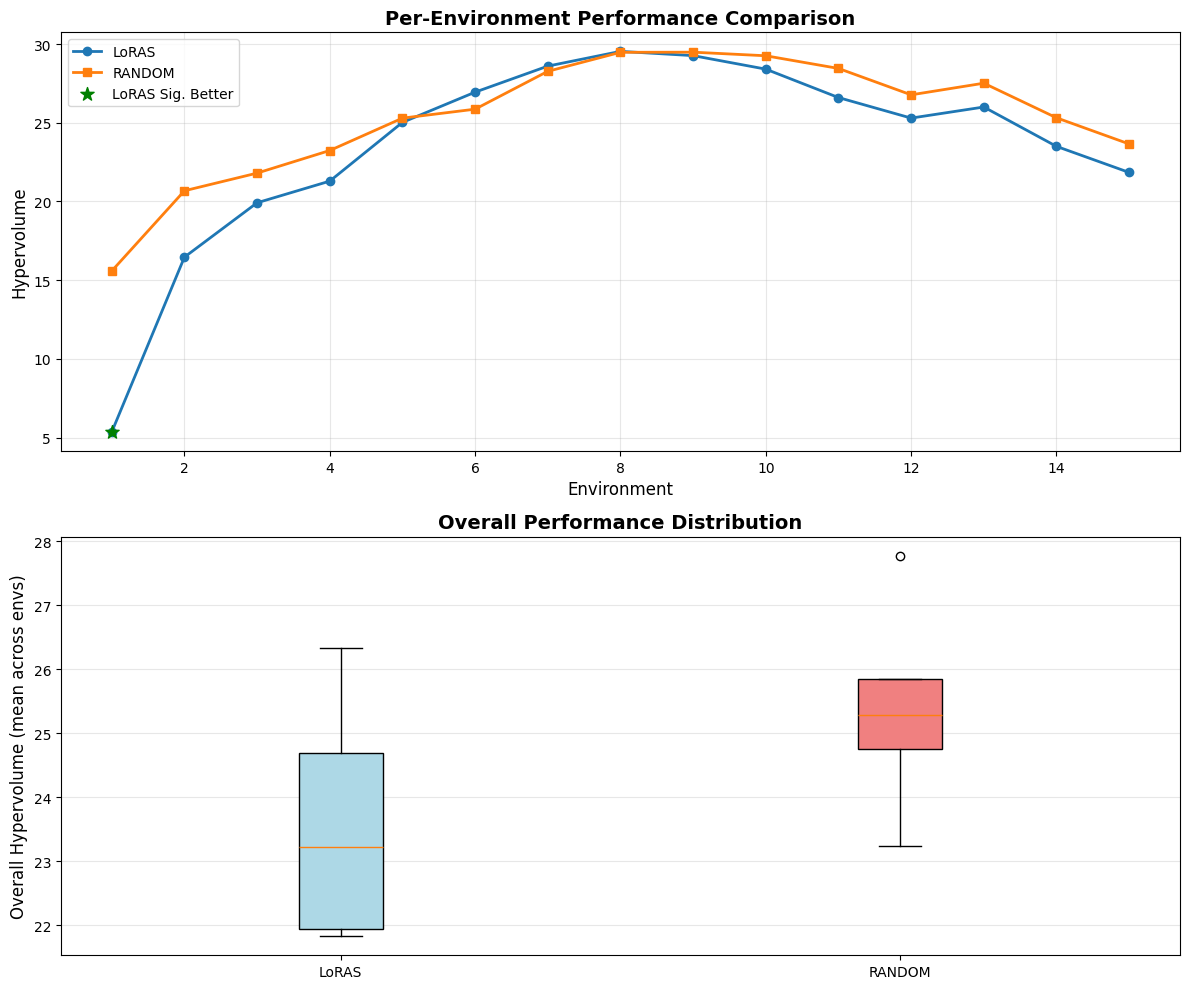

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon, ranksums
import seaborn as sns

def statistical_analysis_per_paper(loras_performances, random_performances, alpha=0.05):
    """
    Statistical analysis following the paper's methodology:
    - Test on EACH environment separately
    - Use Wilcoxon rank sum test at 0.05 significance level
    - Report mean, std, and statistical significance per environment
    
    Inputs:
        loras_performances: array of shape [runs, n_env]
        random_performances: array of shape [runs, n_env]
        alpha: significance level (default 0.05)
    """
    
    loras_perf = np.array(loras_performances)  # shape (runs, n_env)
    random_perf = np.array(random_performances)
    
    n_runs, n_env = loras_perf.shape
    
    print("="*80)
    print("STATISTICAL COMPARISON (Per Environment)")
    print("="*80)
    print(f"Number of runs: {n_runs}")
    print(f"Number of environments: {n_env}")
    print(f"Significance level (alpha): {alpha}")
    print("="*80)
    
    # Storage for results
    results = []
    significant_better_count = 0  # LoRAS significantly better
    significant_worse_count = 0   # LoRAS significantly worse
    no_sig_diff_count = 0         # No significant difference
    
    print("\nPer-Environment Analysis:")
    print("-"*80)
    print(f"{'Env':<5} {'LoRAS Mean':<12} {'LoRAS Std':<12} {'RANDOM Mean':<12} "
          f"{'RANDOM Std':<12} {'p-value':<10} {'Result':<15}")
    print("-"*80)
    
    for e in range(n_env):
        loras_e = loras_perf[:, e]
        random_e = random_perf[:, e]
        
        loras_mean = loras_e.mean()
        loras_std = loras_e.std()
        random_mean = random_e.mean()
        random_std = random_e.std()
        
        # Wilcoxon rank sum test (Mann-Whitney U test for independent samples)
        # Using ranksums which is equivalent to Mann-Whitney U test
        try:
            stat, p_val = ranksums(loras_e, random_e)
        except:
            # If samples are identical, use t-test as fallback
            from scipy.stats import ttest_ind
            stat, p_val = ttest_ind(loras_e, random_e)
        
        # Determine significance
        if p_val < alpha:
            if loras_mean < random_mean:
                result = "LoRAS Better *"
                significant_better_count += 1
            else:
                result = "LoRAS Worse *"
                significant_worse_count += 1
        else:
            result = "No Sig. Diff."
            no_sig_diff_count += 1
        
        print(f"{e+1:<5} {loras_mean:<12.5e} {loras_std:<12.5e} {random_mean:<12.5e} "
              f"{random_std:<12.5e} {p_val:<10.4f} {result:<15}")
        
        results.append({
            'env': e+1,
            'loras_mean': loras_mean,
            'loras_std': loras_std,
            'random_mean': random_mean,
            'random_std': random_std,
            'p_value': p_val,
            'significant': p_val < alpha,
            'loras_better': (p_val < alpha) and (loras_mean < random_mean)
        })
    
    print("-"*80)
    print(f"\nSummary:")
    print(f"  LoRAS significantly better: {significant_better_count}/{n_env}")
    print(f"  LoRAS significantly worse: {significant_worse_count}/{n_env}")
    print(f"  No significant difference: {no_sig_diff_count}/{n_env}")
    print("="*80)
    
    # Overall statistics (averaged over all environments)
    print("\nOverall Performance (Averaged over all environments):")
    print("-"*80)
    loras_overall = loras_perf.mean(axis=1)  # mean per run
    random_overall = random_perf.mean(axis=1)
    
    print(f"LoRAS:  Mean = {loras_overall.mean():.5e}, Std = {loras_overall.std():.5e}")
    print(f"RANDOM: Mean = {random_overall.mean():.5e}, Std = {random_overall.std():.5e}")
    
    # Paired t-test on overall performance
    t_stat, p_overall = ttest_rel(loras_overall, random_overall)
    print(f"\nPaired t-test on overall performance:")
    print(f"  t-statistic = {t_stat:.4f}, p-value = {p_overall:.4f}")
    if p_overall < alpha:
        if loras_overall.mean() < random_overall.mean():
            print(f"  Result: LoRAS is significantly BETTER overall (p < {alpha})")
        else:
            print(f"  Result: LoRAS is significantly WORSE overall (p < {alpha})")
    else:
        print(f"  Result: No significant difference overall (p >= {alpha})")
    
    print("="*80)
    
    # Visualization: Per-environment comparison
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Mean hypervolume per environment
    envs = np.arange(1, n_env + 1)
    loras_means = [r['loras_mean'] for r in results]
    random_means = [r['random_mean'] for r in results]
    
    axes[0].plot(envs, loras_means, marker='o', label='LoRAS', linewidth=2)
    axes[0].plot(envs, random_means, marker='s', label='RANDOM', linewidth=2)
    
    # Highlight significant differences
    for r in results:
        if r['significant']:
            if r['loras_better']:
                axes[0].scatter(r['env'], r['loras_mean'], color='green', s=100, 
                              marker='*', zorder=5, label='LoRAS Sig. Better' if r['env']==1 else "")
            else:
                axes[0].scatter(r['env'], r['loras_mean'], color='red', s=100, 
                              marker='x', zorder=5, label='LoRAS Sig. Worse' if r['env']==1 else "")
    
    axes[0].set_xlabel('Environment', fontsize=12)
    axes[0].set_ylabel('Hypervolume', fontsize=12)
    axes[0].set_title('Per-Environment Performance Comparison', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Boxplot of overall performance
    combined_data = [loras_overall, random_overall]
    bp = axes[1].boxplot(combined_data, labels=['LoRAS', 'RANDOM'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    axes[1].set_ylabel('Overall Hypervolume (mean across envs)', fontsize=12)
    axes[1].set_title('Overall Performance Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return results


def comparative_analysis_with_paper_stats():
    """
    Comparative analysis following the paper's statistical testing approach
    """
    import warnings
    warnings.filterwarnings('ignore')
    
    bounds = np.array([[-2, 2], [-2, 2]])
    runs = 5  # Paper uses 20 runs
    n_env = 15
    n_gen = 10
    minority_samples = np.random.uniform(-2, 2, (10, 2))
    
    loras_performances = []
    random_performances = []
    
    print("Running LoRAS-MOEA ...")
    for seed in range(runs):
        moea_loras = LoRAS_MOEA(pop_size=50, random_state=seed)
        perf = moea_loras.optimize(bounds, n_env=n_env, n_gen=n_gen, 
                                   minority_samples=minority_samples)
        loras_performances.append(perf)
    
    print("Running RANDOM-MOEA ...")
    for seed in range(runs):
        moea_random = MOEA_Random(pop_size=50, random_state=seed)
        perf = moea_random.optimize(bounds, n_env=n_env, n_gen=n_gen, 
                                    minority_samples=minority_samples)
        random_performances.append(perf)
    
    # Convert to numpy arrays
    loras_perf_np = np.array(loras_performances)  # shape: (runs, n_env)
    random_perf_np = np.array(random_performances)
    
    # Perform statistical analysis as per the paper
    results = statistical_analysis_per_paper(loras_perf_np, random_perf_np, alpha=0.05)
    
    return results


if __name__ == "__main__":
    # Make sure LoRAS_MOEA and RANDOM_MOEA classes are defined
    results = comparative_analysis_with_paper_stats()
